In [27]:
import grewpy
import yaml
import sys
import numpy as np

sys.path.insert(1, '/Users/madalina/Documents/M2TAL/stage/grex/grex2')
import pyximport
pyximport.install()
import grex.data
import grex.utils
import grex.features

path = "/Users/madalina/Documents/M1TAL/stage-SK/Treebanks/UD_French-GSD-master"
grewpy.set_config('ud')
corpus = grewpy.Corpus(path)
draft = grewpy.CorpusDraft(corpus)

all_matches = corpus.search(grewpy.Request("pattern{X[upos=ADV]}").without("X[InIdiom=Yes]").without("X[Idiom=Yes]"), clustering_parameter=['X.lemma'])

matches = {}
for key, value in all_matches.items():
    # remove those that have less than 10 occurrences
    if len(value) > 10:
        matches[key] = value

with open("/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/scripts/4. occurrences_as_features/patterns_adv_no_idioms.txt") as instream:
    config = yaml.load(instream, Loader=yaml.Loader)

templates = grex.utils.FeaturePredicate.from_config(config["templates"])
feature_predicate = grex.utils.FeaturePredicate.from_config(config["features"], templates=templates)

In [28]:
data = { k : list() for k in matches }
for adv, mts in matches.items():
    for match in mts:
        features = grex.data.extract_features(draft, match, feature_predicate)
        formatted_features = [
            f"{':'.join(k)}={v}" if not isinstance(v, set) else
            f"{':'.join(k)}={val}" for k, v in features.items() for val in (v if isinstance(v, set) else [v])
        ]
        data[adv].append(formatted_features)

In [29]:
unique_adv = sorted(set([k for k in data]))
unique_features = sorted(set([feat for _, matches in data.items() for m in matches for feat in m]))

idx2feature = {i : feat for i, feat in enumerate(unique_features) }
feature2idx = {feat : i for i, feat in idx2feature.items()}
idx2adv = {i : feat for i, feat in enumerate(unique_adv) }
adv2idx = {feat : i for i, feat in idx2adv.items()}

In [30]:
X = np.zeros((len(data.keys()), len(unique_features)))
for adv, samples in data.items():
    n_samples = len(samples)
    for m in samples:
        for feature in m:
            X[adv2idx[adv], feature2idx[feature]] += 1
    X[adv2idx[adv]] = (X[adv2idx[adv]] / n_samples)*100
print(f"{X.shape=}")

X.shape=(123, 327)


In [16]:
X

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
        71.42857143,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        51.28205128,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         7.89473684,  0.        ],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        23.07692308,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        47.35202492,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        25.        ,  0.        ]])

In [20]:
# i've turned the values of the matrix into percentages
# now i want to get the indices of the features that have a value above 50 for each adverb
indices_above_50 = [list(np.where(row > 50)[0]) for row in X]
dataset = []
for adverb in indices_above_50:
    minilist = []
    for f in adverb:
        minilist.append(idx2feature[f])
    dataset.append(minilist)

print(dataset)

[['node:X:own:rel_shallow=advmod', 'node:X:parent:position=after', 'node:X:prev:VerbForm=Fin', 'node:X:prev:upos=VERB'], ['node:X:own:rel_shallow=advmod', 'node:X:parent:Mood=Ind', 'node:X:parent:Number=Sing', 'node:X:parent:Tense=Pres', 'node:X:parent:VerbForm=Fin', 'node:X:parent:position=before', 'node:X:parent:upos=VERB', 'node:X:prev:Mood=Ind', 'node:X:prev:Number=Sing', 'node:X:prev:Person=3', 'node:X:prev:Tense=Pres', 'node:X:prev:VerbForm=Fin', 'node:X:prev:upos=VERB'], ['node:X:child:Subject=Generic', 'node:X:child:VerbForm=Inf', 'node:X:child:rel_shallow=ccomp', 'node:X:child:upos=VERB', 'node:X:next:upos=ADP', 'node:X:own:rel_shallow=advmod', 'node:X:parent:position=before', 'node:X:parent:upos=VERB'], ['node:X:next:upos=PUNCT', 'node:X:own:rel_shallow=advmod', 'node:X:parent:position=before', 'node:X:parent:upos=VERB'], ['node:X:own:rel_shallow=advmod', 'node:X:parent:Number=Sing', 'node:X:parent:position=after', 'node:X:parent:upos=VERB'], ['node:X:own:rel_shallow=advmod',

In [21]:
%pip install mlxtend

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.8 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [23]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpmax, fpgrowth

te = TransactionEncoder()
te_ary = te.fit(dataset).transform(dataset)
df = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = fpgrowth(df, min_support=0.6, use_colnames=True)

In [24]:
frequent_itemsets

,support,itemsets
0,0.983740,(node:X:own:rel_shallow=advmod)
1,0.634146,(node:X:parent:position=after)
2,0.821138,(node:X:parent:Number=Sing)
3,0.723577,(node:X:parent:upos=VERB)
4,0.634146,"(node:X:own:rel_shallow=advmod, node:X:parent:..."
5,0.821138,"(node:X:parent:Number=Sing, node:X:own:rel_sha..."
6,0.707317,"(node:X:own:rel_shallow=advmod, node:X:parent:..."
7,0.626016,"(node:X:parent:Number=Sing, node:X:parent:upos..."
8,0.626016,"(node:X:parent:Number=Sing, node:X:own:rel_sha..."


In [25]:
from mlxtend.frequent_patterns import association_rules

association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(node:X:parent:position=after),(node:X:own:rel_shallow=advmod),0.634146,0.983740,0.634146,1.000000,1.016529,1.0,0.010311,inf,0.044444,0.644628,1.000000,0.822314
1,(node:X:parent:Number=Sing),(node:X:own:rel_shallow=advmod),0.821138,0.983740,0.821138,1.000000,1.016529,1.0,0.013352,inf,0.090909,0.834711,1.000000,0.917355
2,(node:X:own:rel_shallow=advmod),(node:X:parent:Number=Sing),0.983740,0.821138,0.821138,0.834711,1.016529,1.0,0.013352,1.082114,1.000000,0.834711,0.075883,0.917355
3,(node:X:own:rel_shallow=advmod),(node:X:parent:upos=VERB),0.983740,0.723577,0.707317,0.719008,0.993686,1.0,-0.004495,0.983740,-0.280992,0.707317,-0.016529,0.848268
4,(node:X:parent:upos=VERB),(node:X:own:rel_shallow=advmod),0.723577,0.983740,0.707317,0.977528,0.993686,1.0,-0.004495,0.723577,-0.022472,0.707317,-0.382022,0.848268
5,(node:X:parent:Number=Sing),(node:X:parent:upos=VERB),0.821138,0.723577,0.626016,0.762376,1.053621,1.0,0.031859,1.163279,0.284534,0.681416,0.140361,0.813772
6,(node:X:parent:upos=VERB),(node:X:parent:Number=Sing),0.723577,0.821138,0.626016,0.865169,1.053621,1.0,0.031859,1.326558,0.184110,0.681416,0.246170,0.813772
7,"(node:X:parent:Number=Sing, node:X:own:rel_sha...",(node:X:parent:upos=VERB),0.821138,0.723577,0.626016,0.762376,1.053621,1.0,0.031859,1.163279,0.284534,0.681416,0.140361,0.813772
8,"(node:X:parent:Number=Sing, node:X:parent:upos...",(node:X:own:rel_shallow=advmod),0.626016,0.983740,0.626016,1.000000,1.016529,1.0,0.010179,inf,0.043478,0.636364,1.000000,0.818182
9,"(node:X:own:rel_shallow=advmod, node:X:parent:...",(node:X:parent:Number=Sing),0.707317,0.821138,0.626016,0.885057,1.077842,1.0,0.045211,1.556098,0.246753,0.693694,0.357367,0.823717


Neuron (6, 2): ['absolument', 'plutôt']
Neuron (2, 1): ['actuellement', 'essentiellement', 'généralement', 'maintenant', 'parfois', 'principalement', 'souvent', 'vivement']
Neuron (3, 1): ['afin', 'avant']
Neuron (3, 6): ['ailleurs', 'auparavant']
Neuron (0, 7): ['ainsi']
Neuron (9, 8): ['alors']
Neuron (2, 6): ['après', 'simplement']
Neuron (5, 7): ['assez', 'extrêmement', 'fort', 'non', 'presque', 'relativement', 'très']
Neuron (7, 1): ['au-delà']
Neuron (8, 6): ['au-dessus']
Neuron (6, 7): ["aujourd'hui"]
Neuron (4, 1): ['auprès', 'autour', 'hors', 'vis-à-vis']
Neuron (1, 0): ['aussi']
Neuron (2, 9): ['autant']
Neuron (0, 3): ['autrement']
Neuron (9, 5): ['beaucoup']
Neuron (2, 3): ['bien']
Neuron (3, 2): ['bientôt', 'ensuite', 'finalement', 'également']
Neuron (8, 0): ['cependant', 'certes', 'malheureusement', 'néanmoins', 'pourtant', 'toutefois']
Neuron (9, 9): ['clairement', 'entièrement']
Neuron (3, 5): ['comment', 'ne', 'pourquoi']
Neuron (9, 0): ['complètement', 'pratiquement'

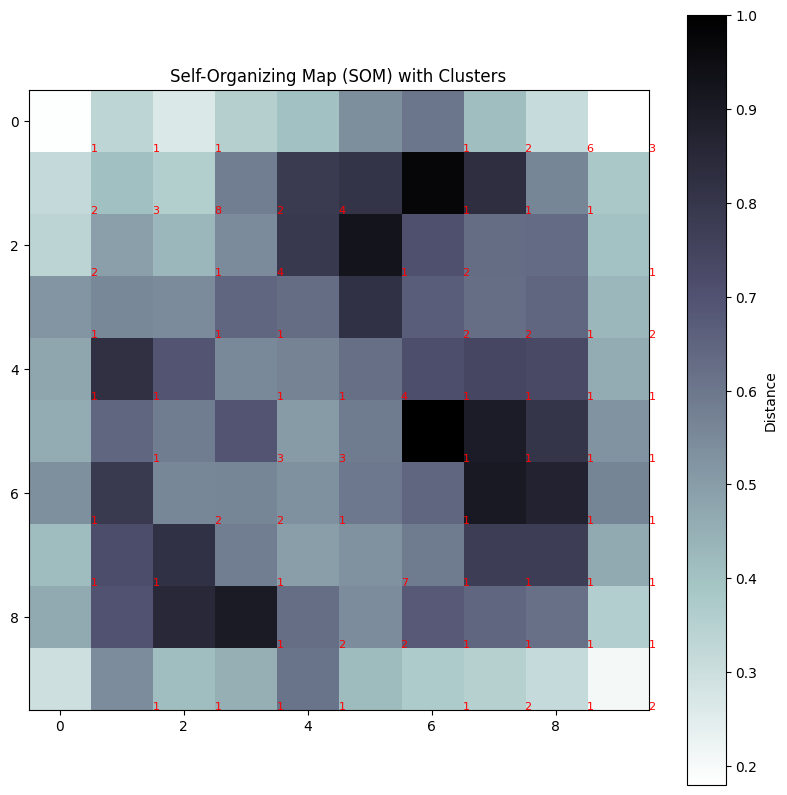

In [31]:
from minisom import MiniSom
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Normalize the data
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

# Initialize the SOM
som = MiniSom(x=10, y=10, input_len=X.shape[1], sigma=1.0, learning_rate=0.5)
som.random_weights_init(X_normalized)

# Train the SOM
som.train_random(X_normalized, num_iteration=100)

# Map each data point to its winning neuron
winning_neurons = np.array([som.winner(x) for x in X_normalized])

# Group data points by their winning neurons
clusters = {}
for i, neuron in enumerate(winning_neurons):
    neuron = tuple(neuron)  # Convert numpy array to tuple
    if neuron not in clusters:
        clusters[neuron] = []
    clusters[neuron].append(i)

# Map cluster indices back to original data (adv keys)
clustered_data = {}
for neuron, indices in clusters.items():
    clustered_data[neuron] = [list(adv2idx.keys())[i] for i in indices]

# Print the clusters with original data keys
for neuron, adv_keys in clustered_data.items():
    print(f"Neuron {neuron}: {adv_keys}")

# Visualize the SOM with cluster labels
plt.figure(figsize=(10, 10))
for neuron, indices in clusters.items():
    plt.text(neuron[0] + 0.5, neuron[1] + 0.5, str(len(indices)), color='red', fontsize=8)  # Show cluster size

plt.title("Self-Organizing Map (SOM) with Clusters")
plt.imshow(som.distance_map().T, cmap='bone_r')  # Distance map as background
plt.colorbar(label='Distance')
plt.show()

In [35]:
# Create a scatter plot
import plotly.graph_objects as go
fig = go.Figure()

# Add a scatter trace for each neuron
for neuron, words in clustered_data.items():
    fig.add_trace(go.Scatter(
        x=[neuron[0]],
        y=[neuron[1]],
        text=['<br>'.join(words)],  # Join words with line breaks for hover text
        mode='markers+text',
        marker=dict(size=10),
        textfont=dict(size=10),
        hoverinfo='text'
    ))

# Update layout
fig.update_layout(
    title="Self-Organizing Map (SOM) with Clusters",
    xaxis=dict(title='X Coordinate', tickvals=list(range(10))),
    yaxis=dict(title='Y Coordinate', tickvals=list(range(10)), scaleanchor="x"),
    width=800,
    height=800
)

# Show the figure
fig.show()

This on adverbs isn't very interesting - we seem stuck in "obvious" patterns like the relationship being advmod or the parent being a verb, though i guess we can use this for understanding what the co-occurring characterstics are in each cluster? 

In [36]:
import grewpy
import yaml
import sys
import numpy as np

sys.path.insert(1, '/Users/madalina/Documents/M2TAL/stage/grex/grex2')
import pyximport
pyximport.install()
import grex.data
import grex.utils
import grex.features

# path = "/Users/madalina/Documents/M1TAL/stage-SK/Treebanks/UD_French-GSD-master"
# grewpy.set_config('ud')
path = "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/data/input/Universal_Dependencies/ud-treebanks-v2.15/UD_Romanian-RRT"
grewpy.set_config('ud')
corpus = grewpy.Corpus(path)
draft = grewpy.CorpusDraft(corpus)

all_matches = corpus.search(grewpy.Request("pattern{X[upos<>PUNCT]}").without("X[InIdiom=Yes]").without("X[Idiom=Yes]").without("X[InTitle=Yes]").without("X[Title=Yes]").without("X[Scrap=Yes]").without("X[Foreign]").without("X[Lang]").without("X-[fixed]->Y").without("Y-[flat:name]->X").without("Y-[goeswith]->X") , clustering_parameter=['X.lemma'])

In [37]:
matches = {}
for key, value in all_matches.items():
    # remove those that have less than 10 occurrences
    if len(value) > 10:
        matches[key] = value
# Create a dictionary to map sent_id to sentences for quick lookup
sent_id_to_sentence = {draft[i].meta['sent_id']: draft[i].features for i in range(len(draft))}

match_upos = {}
for key, value in matches.items():
    for m in value:
        match_sent_id = m['sent_id']
        match_node_index = str(m['matching']['nodes']['X'])
        if match_sent_id in sent_id_to_sentence:
            current_sentence_features = sent_id_to_sentence[match_sent_id]
            if match_node_index in current_sentence_features.keys():
                current_token_features = current_sentence_features[match_node_index]
                if 'ExtPos' in current_token_features:
                    match_upos.setdefault((key, current_token_features['ExtPos']), []).append(m)
                else:
                    match_upos.setdefault((key, current_token_features['upos']), []).append(m)

new_match_upos = {}
for key, value in match_upos.items():
    if len(value) > 10:
        new_match_upos[key] = value
match_upos = new_match_upos

for key, value in match_upos.items():
    print(key, len(value))

('țăran', 'NOUN') 15
('ține', 'VERB') 67
('țigară', 'NOUN') 11
('țesut', 'NOUN') 16
('țară', 'NOUN') 188
('știință', 'NOUN') 19
('științific', 'ADJ') 40
('ști', 'VERB') 142
('șterge', 'VERB') 11
('șold', 'NOUN') 12
('șir', 'NOUN') 30
('și', 'CCONJ') 5312
('șef', 'NOUN') 22
('ședință', 'NOUN') 11
('școală', 'NOUN') 38
('șase', 'NUM') 38
('șapte', 'NUM') 30
('Ștefan', 'PROPN') 17
('înțelegere', 'NOUN') 16
('înțelege', 'VERB') 50
('înălțime', 'NOUN') 11
('învățământ', 'NOUN') 18
('învăța', 'VERB') 15
('întări', 'VERB') 26
('întârzia', 'VERB') 12
('întâmplare', 'NOUN') 18
('întâmpla', 'VERB') 54
('întâlnire', 'NOUN') 19
('întâlni', 'VERB') 36
('întâi', 'ADV') 13
('întâi', 'NUM') 15
('întuneric', 'NOUN') 12
('întrucât', 'SCONJ') 11
('întru', 'ADP') 332
('întreținere', 'NOUN') 14
('întreține', 'VERB') 14
('întrerupere', 'NOUN') 30
('întrerupe', 'VERB') 31
('întreprindere', 'NOUN') 21
('întreprinde', 'VERB') 17
('întregime', 'NOUN') 14
('întreg', 'ADJ') 83
('întrebare', 'NOUN') 17
('întreba',

In [38]:
with open("/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/scripts/3. probability_matrix/patterns_all_nodes.txt") as instream:
    config = yaml.load(instream, Loader=yaml.Loader)

templates = grex.utils.FeaturePredicate.from_config(config["templates"])
feature_predicate = grex.utils.FeaturePredicate.from_config(config["features"], templates=templates)

In [39]:
data = { k : list() for k in match_upos }
for node, mts in match_upos.items():
    for match in mts:
        features = grex.data.extract_features(draft, match, feature_predicate)
        formatted_features = [
            f"{':'.join(k)}={v}" if not isinstance(v, set) else
            f"{':'.join(k)}={val}" for k, v in features.items() for val in (v if isinstance(v, set) else [v])
        ]
        data[node].append(formatted_features)

In [40]:
unique_lemma = sorted(set([k for k in data]))
unique_features = sorted(set([feat for _, match_upos in data.items() for m in match_upos for feat in m]))

idx2feature = {i : feat for i, feat in enumerate(unique_features) }
feature2idx = {feat : i for i, feat in idx2feature.items()}
idx2adv = {i : feat for i, feat in enumerate(unique_lemma) }
adv2idx = {feat : i for i, feat in idx2adv.items()}

In [41]:
X = np.zeros((len(data.keys()), len(unique_features)))
for adv, samples in data.items():
    n_samples = len(samples)
    for m in samples:
        for feature in m:
            X[adv2idx[adv], feature2idx[feature]] += 1
    X[adv2idx[adv]] = (X[adv2idx[adv]] / n_samples)*100
print(f"{X.shape=}")

X.shape=(2198, 560)


In [32]:
indices_above_50 = [list(np.where(row > 50)[0]) for row in X]
dataset = []
for adverb in indices_above_50:
    minilist = []
    for f in adverb:
        minilist.append(idx2feature[f])
    dataset.append(minilist)

In [36]:
dataset

[['node:X:next:Gender=Fem',
  'node:X:next:Number=Sing',
  'node:X:own:Definite=Def',
  'node:X:own:Gender=Fem',
  'node:X:own:Number=Sing',
  'node:X:own:PronType=Art',
  'node:X:own:Variant=Short',
  'node:X:own:rel_shallow=det',
  'node:X:parent:NumType=Ord',
  'node:X:parent:Number=Sing',
  'node:X:parent:position=before',
  'node:X:parent:upos=NUM',
  'node:X:prev:Number=Sing',
  'node:X:prev:upos=NUM'],
 ['node:X:own:Definite=Def',
  'node:X:own:Gender=Masc',
  'node:X:own:Number=Sing',
  'node:X:own:PronType=Art',
  'node:X:own:Variant=Short',
  'node:X:own:rel_shallow=det',
  'node:X:parent:NumForm=Roman',
  'node:X:parent:NumType=Ord',
  'node:X:parent:Number=Sing',
  'node:X:parent:position=before',
  'node:X:parent:upos=NUM',
  'node:X:prev:NumForm=Roman',
  'node:X:prev:NumType=Ord',
  'node:X:prev:Number=Sing',
  'node:X:prev:upos=NUM'],
 ['node:X:own:Case=Acc,Nom',
  'node:X:own:Definite=Def',
  'node:X:own:Gender=Masc',
  'node:X:own:Number=Sing',
  'node:X:own:PronType=

In [37]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpmax, fpgrowth

te = TransactionEncoder()
te_ary = te.fit(dataset).transform(dataset)
df = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = fpgrowth(df, min_support=0.3, use_colnames=True)

In [38]:
frequent_itemsets

,support,itemsets
0,0.893085,(node:X:parent:position=before)
1,0.601456,(node:X:own:Number=Sing)
2,0.512739,(node:X:parent:Number=Sing)
3,0.403094,(node:X:own:Gender=Fem)
4,0.357143,(node:X:parent:upos=NOUN)
5,0.307097,"(node:X:own:Case=Acc,Nom)"
6,0.318016,(node:X:own:Definite=Ind)
7,0.339854,(node:X:parent:upos=VERB)
8,0.444495,(node:X:child:Number=Sing)
9,0.353503,(node:X:child:Gender=Fem)


In [39]:
from mlxtend.frequent_patterns import association_rules

association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(node:X:own:Number=Sing),(node:X:parent:position=before),0.601456,0.893085,0.563239,0.936460,1.048568,1.0,0.026088,1.682644,0.116219,0.604787,0.405697,0.783564
1,(node:X:parent:Number=Sing),(node:X:parent:position=before),0.512739,0.893085,0.456324,0.889973,0.996516,1.0,-0.001595,0.971723,-0.007123,0.480594,-0.029100,0.700463
2,(node:X:parent:Number=Sing),(node:X:own:Number=Sing),0.512739,0.601456,0.369882,0.721384,1.199397,1.0,0.061492,1.430443,0.341188,0.496944,0.300916,0.668181
3,"(node:X:parent:Number=Sing, node:X:parent:posi...",(node:X:own:Number=Sing),0.456324,0.601456,0.352138,0.771685,1.283028,1.0,0.077680,1.745588,0.405745,0.499033,0.427127,0.678581
4,"(node:X:parent:Number=Sing, node:X:own:Number=...",(node:X:parent:position=before),0.369882,0.893085,0.352138,0.952030,1.066001,1.0,0.021803,2.228774,0.098259,0.386613,0.551323,0.673162
5,(node:X:own:Gender=Fem),(node:X:parent:position=before),0.403094,0.893085,0.387170,0.960497,1.075482,1.0,0.027173,2.706486,0.117580,0.425926,0.630517,0.697008
6,(node:X:own:Definite=Ind),(node:X:parent:position=before),0.318016,0.893085,0.309827,0.974249,1.090881,1.0,0.025812,4.151880,0.122158,0.343766,0.759145,0.660583
7,(node:X:parent:upos=VERB),(node:X:parent:position=before),0.339854,0.893085,0.309827,0.911647,1.020784,1.0,0.006308,1.210088,0.030843,0.335633,0.173614,0.629282
8,(node:X:child:Number=Sing),(node:X:parent:position=before),0.444495,0.893085,0.439490,0.988741,1.107108,1.0,0.042519,9.496029,0.174158,0.489362,0.894693,0.740422
9,(node:X:child:Gender=Fem),(node:X:parent:position=before),0.353503,0.893085,0.350318,0.990991,1.109627,1.0,0.034610,11.867607,0.152818,0.390863,0.915737,0.691624


In [40]:
%pip install MiniSom

  Preparing metadata (setup.py) ... done
  Created wheel for MiniSom: filename=MiniSom-2.3.5-py3-none-any.whl size=12031 sha256=ca0493b2ee87c4ea25c6263854aee0cbb4bef062525d9378fa8d99bde64bb049
  Stored in directory: /Users/madalina/Library/Caches/pip/wheels/19/db/95/5e53bc2b88a328217fdf9f2886cafbe86b0df274f4b601f572
Successfully built MiniSom

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Neuron (4, 5): [('-a', 'DET'), ('-lea', 'DET'), ('-ul', 'DET'), ('-ului', 'DET')]
Neuron (4, 2): [('0', 'NUM'), ('10', 'NUM'), ('13', 'NUM'), ('14', 'NUM'), ('16', 'NUM'), ('18', 'NUM'), ('28', 'NUM')]
Neuron (4, 3): [('1', 'NUM'), ('11', 'NUM'), ('17', 'NUM'), ('2', 'NUM'), ('3', 'NUM'), ('4', 'NUM'), ('5', 'NUM'), ('6', 'NUM'), ('7', 'NUM'), ('8', 'NUM'), ('9', 'NUM')]
Neuron (5, 1): [('100', 'NUM'), ('20', 'NUM'), ('24', 'NUM'), ('25', 'NUM'), ('40', 'NUM'), ('48', 'NUM'), ('50', 'NUM'), ('60', 'NUM'), ('80', 'NUM')]
Neuron (5, 2): [('12', 'NUM'), ('15', 'NUM'), ('19', 'NUM'), ('21', 'NUM'), ('23', 'NUM'), ('26', 'NUM'), ('27', 'NUM'), ('29', 'NUM'), ('30', 'NUM'), ('31', 'NUM'), ('fiecare', 'DET')]
Neuron (6, 1): [('17-beta', 'NUM'), ('1989', 'NUM'), ('1990', 'NUM'), ('1991', 'NUM'), ('1999', 'NUM'), ('2000', 'NUM'), ('2001', 'NUM'), ('2002', 'NUM'), ('2003', 'NUM'), ('2004', 'NUM'), ('2005', 'NUM'), ('2006', 'NUM'), ('2007', 'NUM'), ('96', 'NUM')]
Neuron (6, 2): [('22', 'NUM')]
Ne

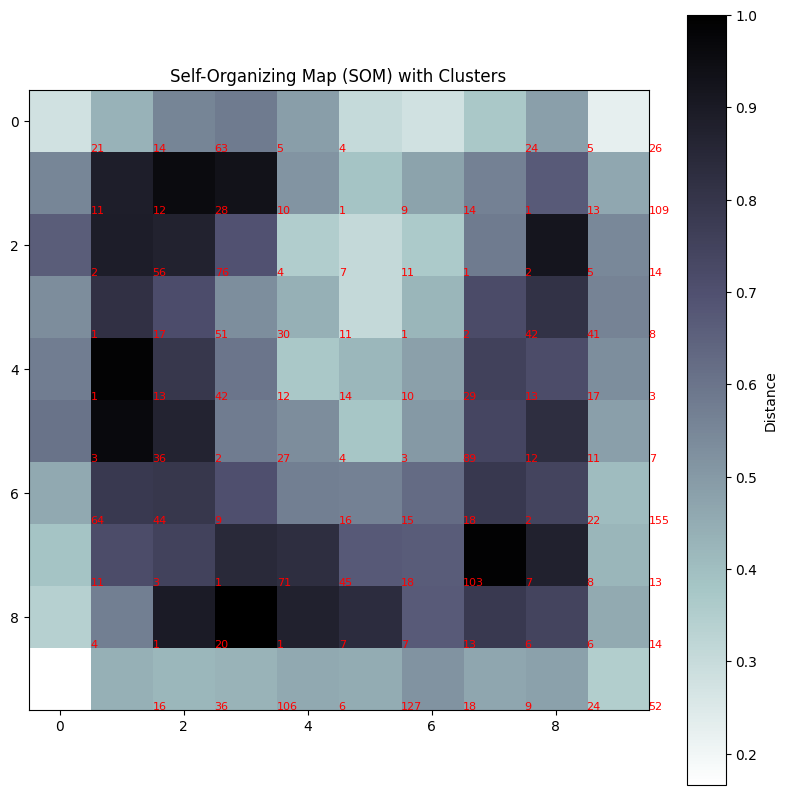

In [42]:
from minisom import MiniSom
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Normalize the data
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

# Initialize the SOM
som = MiniSom(x=10, y=10, input_len=X.shape[1], sigma=1.0, learning_rate=0.5)
som.random_weights_init(X_normalized)

# Train the SOM
som.train_random(X_normalized, num_iteration=100)

# Map each data point to its winning neuron
winning_neurons = np.array([som.winner(x) for x in X_normalized])

# Group data points by their winning neurons
clusters = {}
for i, neuron in enumerate(winning_neurons):
    neuron = tuple(neuron)  # Convert numpy array to tuple
    if neuron not in clusters:
        clusters[neuron] = []
    clusters[neuron].append(i)

# Map cluster indices back to original data (adv keys)
clustered_data = {}
for neuron, indices in clusters.items():
    clustered_data[neuron] = [list(adv2idx.keys())[i] for i in indices]

# Print the clusters with original data keys
for neuron, adv_keys in clustered_data.items():
    print(f"Neuron {neuron}: {adv_keys}")

# Visualize the SOM with cluster labels
plt.figure(figsize=(10, 10))
for neuron, indices in clusters.items():
    plt.text(neuron[0] + 0.5, neuron[1] + 0.5, str(len(indices)), color='red', fontsize=8)  # Show cluster size

plt.title("Self-Organizing Map (SOM) with Clusters")
plt.imshow(som.distance_map().T, cmap='bone_r')  # Distance map as background
plt.colorbar(label='Distance')
plt.show()

In [47]:
# Create a scatter plot
import plotly.graph_objects as go
fig = go.Figure()
box_text = ""
# Add a scatter trace for each neuron
for neuron, words in clustered_data.items():
    for t in words:
        box_text += f"{t}<br>"
    fig.add_trace(go.Scatter(
        x=[neuron[0]],
        y=[neuron[1]],
        text=[box_text],  # Join words with line breaks for hover text
        # mode='markers+text',
        # marker=dict(size=10),
        textfont=dict(size=10),
        hoverinfo='text'
    ))
    box_text = ""

# Update layout
fig.update_layout(
    title="Self-Organizing Map (SOM) with Clusters",
    xaxis=dict(title='X Coordinate', tickvals=list(range(10))),
    yaxis=dict(title='Y Coordinate', tickvals=list(range(10)), scaleanchor="x"),
    width=800,
    height=800
)

# Show the figure
fig.show()

In [49]:
fig.write_html("som_clusters_romanian.html")

In [26]:
import plotly.express as px
import numpy as np
from minisom import MiniSom
from sklearn.preprocessing import MinMaxScaler

# Normalize the data
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

# Initialize the SOM
som = MiniSom(x=10, y=10, input_len=X.shape[1], sigma=1.0, learning_rate=0.5)
som.random_weights_init(X_normalized)

# Train the SOM
som.train_random(X_normalized, num_iteration=100)

# Map each data point to its winning neuron
winning_neurons = np.array([som.winner(x) for x in X_normalized])

# Group data points by their winning neurons
clusters = {}
for i, neuron in enumerate(winning_neurons):
    neuron = tuple(neuron)  # Convert numpy array to tuple
    if neuron not in clusters:
        clusters[neuron] = []
    clusters[neuron].append(i)

# Map cluster indices back to original data (adv keys)
clustered_data = {}
for neuron, indices in clusters.items():
    clustered_data[neuron] = [list(adv2idx.keys())[i] for i in indices]

# Prepare data for Plotly scatter plot
cluster_labels = []
x_coords = []
y_coords = []
hover_texts = []

for neuron, indices in clusters.items():
    for idx in indices:
        cluster_labels.append(str(neuron))
        x_coords.append(X_normalized[idx][0])
        y_coords.append(X_normalized[idx][1])
        hover_texts.append(f"Cluster: {neuron}<br>Key: {list(adv2idx.keys())[idx]}")

# Create a DataFrame for Plotly
import pandas as pd
df = pd.DataFrame({
    'Cluster': cluster_labels,
    'X': x_coords,
    'Y': y_coords,
    'Hover': hover_texts
})

# Create a scatter plot with Plotly Express
fig = px.scatter(df, x='X', y='Y', color='Cluster',
                 title="Self-Organizing Map (SOM) Clusters",
                 labels={'Cluster': 'Cluster'},
                 hover_name='Hover',
                 color_discrete_sequence=px.colors.qualitative.Plotly)

# Update layout for better visualization
fig.update_layout(
    width=800,
    height=800,
    xaxis_title="Feature 1",
    yaxis_title="Feature 2"
)

# Show the figure
fig.show()


In [46]:
X

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.        , 54.54545455, 54.54545455, ...,  0.        ,
         9.09090909,  0.        ],
       [ 0.        , 10.44776119, 34.32835821, ...,  1.49253731,
         0.        ,  0.        ],
       [ 0.        , 33.33333333, 33.33333333, ...,  0.        ,
         0.        ,  0.        ]])

In [12]:
from minisom import MiniSom
import numpy as np
from sklearn.preprocessing import MinMaxScaler
# data normalization
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

# Initialization and training
som_shape = (5, 11)
som = MiniSom(som_shape[0], som_shape[1], X_normalized.shape[1], sigma=.5, learning_rate=.5,
              neighborhood_function='gaussian', random_seed=10)

som.train_batch(X_normalized, 1000, verbose=True)

 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 1.8052382997809766


In [13]:
# each neuron represents a cluster
winner_coordinates = np.array([som.winner(x) for x in X_normalized]).T
# with np.ravel_multi_index we convert the bidimensional
# coordinates to a monodimensional index
cluster_index = np.ravel_multi_index(winner_coordinates, som_shape)

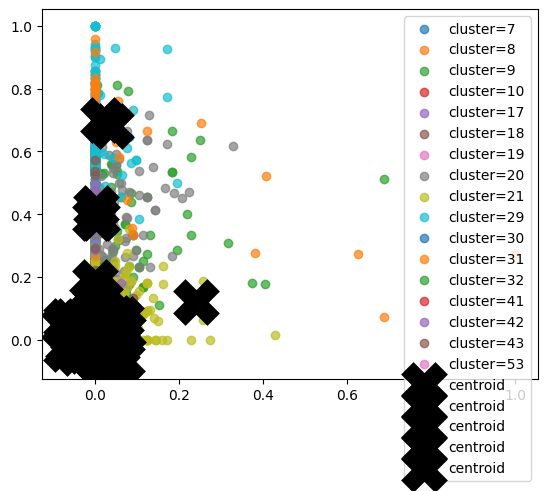

In [14]:
import matplotlib.pyplot as plt
%matplotlib inline

# plotting the clusters using the first 2 dimentions of the data
for c in np.unique(cluster_index):
    plt.scatter(X_normalized[cluster_index == c, 0],
                X_normalized[cluster_index == c, 1], label='cluster='+str(c), alpha=.7)

# plotting centroids
for centroid in som.get_weights():
    plt.scatter(centroid[:, 0], centroid[:, 1], marker='x', 
                s=80, linewidths=35, color='k', label='centroid')
plt.legend()